In [6]:
import numpy as np

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math
import random
import matplotlib.pyplot as plt
import json

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

torch.manual_seed(42)
np.random.seed(42)

Device : cuda


### Task 1: Dataset Loading and Inspection

#### 1.1 Dataset Ingestion

In [2]:
def load_data(file_path):
    src, tgt, length_bucket = [], [], []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data = json.loads(line)
                src.append(data['src'])
                tgt.append(data['tgt'])
                length_bucket.append(data['length_bucket'])
    return src, tgt, length_bucket


In [3]:
train_src, train_tgt, train_lb = load_data('train.jsonl')
test_src, test_tgt, test_lb = load_data('test.jsonl')
val_src, val_tgt, val_lb = load_data('val.jsonl')

print(f"No.of examples in each split: Train - {len(train_src)} | Test - {len(test_src)} | Val - {len(val_src)}")

No.of examples in each split: Train - 6000 | Test - 800 | Val - 800


In [4]:
print(f"Sample pair: Source - {train_src[67]} | Target - {train_tgt[67]}")

Sample pair: Source - the swift queen feeds the blue cloud and the young wizard follows the happy mountain and the swift dragon throws the swift mountain | Target - swiai mouex swiai draol thrun yol hapai mouex youai wizol folun yol bluai cloex swiai queol feeun


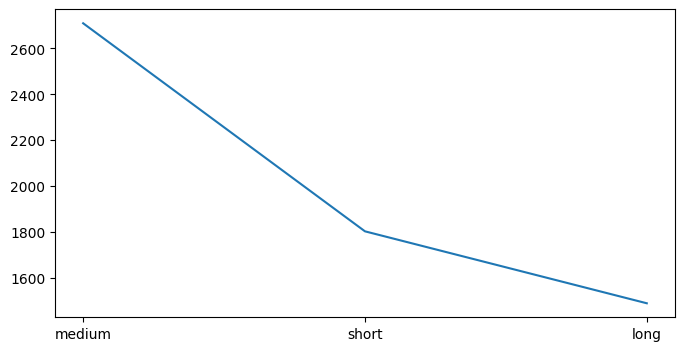

In [22]:
from collections import Counter

bucket_freq = Counter(train_lb)
x = bucket_freq.keys()
y = bucket_freq.values()
plt.figure(figsize=(8,4))
plt.plot(x,y)
plt.show()

### Task 2: Preprocessing and Length-Aware Pipeline

#### 2.1 Vocabulary and Numericalization

In [23]:
def tokenize(text):
    return text.lower().split()

In [24]:
MAX_LEN = 50
pad_idx, sos_idx, eos_idx, unk_idx = 0,1,2,3

In [25]:
def generate_vocab(sentences):
    token2idx = {"<pad>" : pad_idx, "<sos>" : sos_idx, "<eos>" : eos_idx, "<unk>" : unk_idx}
    idx2token = {pad_idx : "<pad>", sos_idx : "<sos>", eos_idx : "<eos>", unk_idx : "<unk>"}
    i = 4
    for s in sentences:
        for token in tokenize(s):
            if token not in token2idx:
                token2idx[token] = i
                idx2token[i] = token
                i += 1
    return token2idx, idx2token

In [26]:
src_t2i, src_i2t = generate_vocab(train_src)
tgt_t2i, tgt_i2t = generate_vocab(train_tgt)

In [27]:
def encode_sentence(sentence, token2idx, max_len=MAX_LEN):
    tokens = tokenize(sentence)
    tokens = tokens[:max_len]
    ids = [sos_idx] + [token2idx.get(tok, unk_idx) for tok in tokens] + [eos_idx]
    if len(ids) < max_len:
        ids += [pad_idx] * (max_len - len(ids))
    return ids

#### 2.2 Mini-Batch Generation

In [ ]:
class DataGenerator(Dataset):
    def __init__(self, source_sentences, source_vocab, target_sentences, target_vocab):
        self.source_data = [encode_sentence(s, source_vocab) for s in source_sentences]
        self.target_data = [encode_sentence(t, target_vocab) for t in target_sentences]
    def __len__(self):
        return len(self.source_data)
    def __getitem__(self,index):
        return (torch.tensor(self.source_data[index], dtype=torch.long)), (torch.tensor(self.target_data[index], dtype=torch.long))

In [ ]:
def get_batches(source_sent, target_sent, source_vocab, target_vocab, batch_size, shuffle=True):
    dataset = DataGenerator(source_sent, source_vocab, target_sent, target_vocab)
    dl = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    for source_batch, target_batch in dl:
        yield source_batch.to(device), target_batch.to(device)

### Task 3: BPTT Mathematics

#### 3.1 Scalar BPTT Simulation

In [39]:
def simulate_bptt(w, seq_length=50):
    gradients = []
    g = 1
    for t in range(50,0,-1):
        print(f"Time step {t}: {g}")
        gradients.append(g)
        g = w * g
    return gradients

In [40]:
w1 = 0.92
sim1 = simulate_bptt(w1, 50)

Time step 50: 1
Time step 49: 0.92
Time step 48: 0.8464
Time step 47: 0.778688
Time step 46: 0.7163929600000001
Time step 45: 0.6590815232000001
Time step 44: 0.6063550013440001
Time step 43: 0.5578466012364801
Time step 42: 0.5132188731375618
Time step 41: 0.47216136328655683
Time step 40: 0.4343884542236323
Time step 39: 0.3996373778857418
Time step 38: 0.36766638765488246
Time step 37: 0.3382530766424919
Time step 36: 0.31119283051109253
Time step 35: 0.28629740407020515
Time step 34: 0.26339361174458875
Time step 33: 0.24232212280502166
Time step 32: 0.22293635298061995
Time step 31: 0.20510144474217037
Time step 30: 0.18869332916279674
Time step 29: 0.17359786282977302
Time step 28: 0.1597100338033912
Time step 27: 0.1469332310991199
Time step 26: 0.13517857261119032
Time step 25: 0.1243642868022951
Time step 24: 0.1144151438581115
Time step 23: 0.10526193234946259
Time step 22: 0.09684097776150559
Time step 21: 0.08909369954058514
Time step 20: 0.08196620357733833
Time step 19: 0

In [41]:
w2 = 1.08
sim2 = simulate_bptt(w2, 50)

Time step 50: 1
Time step 49: 1.08
Time step 48: 1.1664
Time step 47: 1.2597120000000002
Time step 46: 1.3604889600000003
Time step 45: 1.4693280768000003
Time step 44: 1.5868743229440005
Time step 43: 1.7138242687795207
Time step 42: 1.8509302102818825
Time step 41: 1.9990046271044333
Time step 40: 2.158924997272788
Time step 39: 2.331638997054611
Time step 38: 2.5181701168189803
Time step 37: 2.719623726164499
Time step 36: 2.937193624257659
Time step 35: 3.172169114198272
Time step 34: 3.425942643334134
Time step 33: 3.7000180548008648
Time step 32: 3.9960194991849343
Time step 31: 4.315701059119729
Time step 30: 4.660957143849308
Time step 29: 5.033833715357253
Time step 28: 5.436540412585834
Time step 27: 5.871463645592701
Time step 26: 6.341180737240118
Time step 25: 6.848475196219328
Time step 24: 7.396353211916876
Time step 23: 7.988061468870226
Time step 22: 8.627106386379845
Time step 21: 9.317274897290233
Time step 20: 10.062656889073452
Time step 19: 10.867669440199329
Time

If w < 1 then gradient exponentially decrease towards 0 else if w > 1 the gradients exponentially increases i.e. the gradients diverge

#### 3.2 Gradient Trajectory

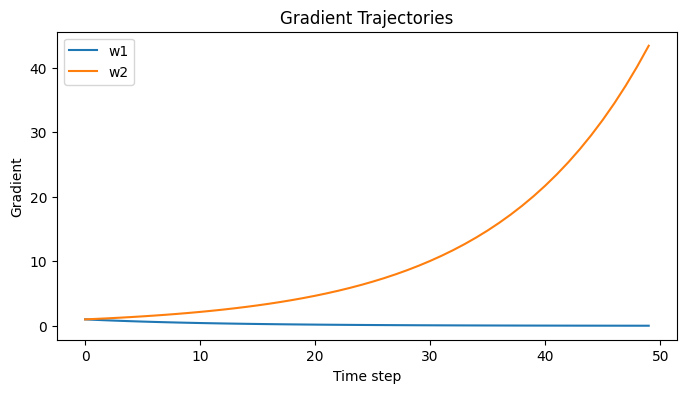

In [45]:
plt.figure(figsize=(8,4))
plt.plot(sim1, label='w1')
plt.plot(sim2, label='w2')
plt.title('Gradient Trajectories')
plt.xlabel('Time step')
plt.ylabel('Gradient')
plt.legend()
plt.show()

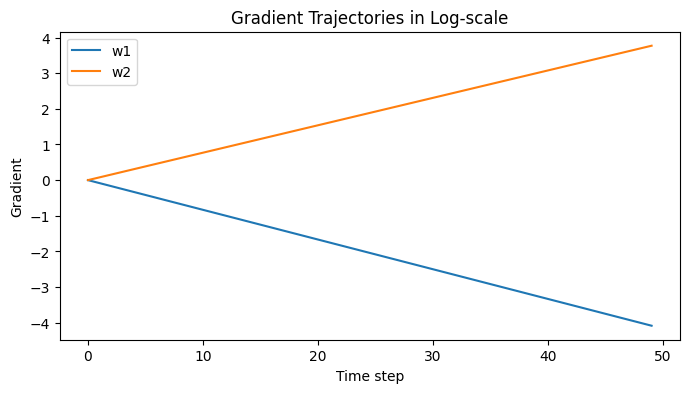

In [46]:
plt.figure(figsize=(8,4))
plt.plot(np.log(sim1), label='w1')
plt.plot(np.log(sim2), label='w2')
plt.title('Gradient Trajectories in Log-scale')
plt.xlabel('Time step')
plt.ylabel('Gradient')
plt.legend()
plt.show()

### Task 4: Custom Masked Seq2Seq Architecture

#### 4.1 Masked Unrolled Encoder

In [47]:
BATCH_SIZE = 64
EMBED_DIM = 64
HIDDEN_DIM = 128
LEARNING_RATE = 0.001

In [49]:
class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size, nonlinearity="tanh", init_gain=1.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.nonlinearity = nonlinearity
        self.W_ih = nn.Parameter(torch.empty(hidden_size, input_size))
        self.W_hh = nn.Parameter(torch.empty(hidden_size, hidden_size))
        self.b_hh = nn.Parameter(torch.empty(hidden_size))
        self.reset_parameters(init_gain)

    def reset_parameters(self, gain=1.0):
        for p in self.parameters():
            _uniform_init(p, self.hidden_size, gain)

    def forward(self, x, h):
        pre = x @ self.W_ih.T + self.b_ih + h @ self.W_hh.T + self.b_hh
        return torch.tanh(pre) if self.nonlinearity == "tanh" else torch.relu(pre)

In [ ]:
# def forward(self, inputs, mask, prev_state=None):
# outputs = []
# for X in inputs:
#     candi_state = torch.tanh(torch.matmul(X, self.W_xh) + torch.matmul(prev_state, self.W_hh) + self.b_h)
#     curr_state = torch.matmul(candi_state, mask) + torch.matmul(prev_state, 1 - mask)
#     outputs.append(curr_state)
# return outputs, curr_state

In [ ]:
class myRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1,
        init_gain=1.0, nonlinearity="tanh"):
        super().__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        kw = {"nonlinearity": nonlinearity}
        self.cells = nn.ModuleList([(input_size if l == 0 else hidden_size,hidden_size, init_gain=init_gain, **kw) for l in range(num_layers)])
        self.hidden_states = []

    def init_state(self, batch, device):
        h = [torch.zeros(batch, self.hidden_size, device=device) for _ in range(self.num_layers)]
        return h

    def forward(self, x, state=None, retain_hidden=False):
        B, T, _ = x.shape
        state = self.init_state(B, x.device) if state is None else state
        self.hidden_states = []
        outputs = []
        for t in range(T):
            inp = x[:, t]
        for l, cell in enumerate(self.cells):
            h = cell(inp, state[l])
            state[l] = h
            inp = h
            if retain_hidden:
                inp.retain_grad()
                self.hidden_states.append(inp)
                outputs.append(inp)
        return torch.stack(outputs, dim=1), state

    def final_hidden(self, state):
        top = state[-1]
        return top

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (2208068346.py, line 8)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=EMBED_DIM, hidden=HIDDEN_DIM,):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.rnn = myRNN(emb_dim, hidden)

    def forward(self, src, retain_hidden=False):
        emb = self.dropout(self.embedding(src))
        outputs, state = self.rnn(emb, retain_hidden=retain_hidden)
        return outputs, state

#### 4.2 Autoregressive Decoder

In [ ]:
class Decoder(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

In [54]:
@torch.no_grad()
def greedy_decode(model, src, max_len=MAX_LEN, device=device):
    model.eval()
    src = src.to(device)
    src_pad_mask = src == pad_idx
    enc_outputs, state = model.encoder(src)
    fixed = model._fixed_context(enc_outputs, state)
    token = torch.tensor([sos_idx], device=device)
    out= []
    for _ in range(max_len):
        logits, state, = model.decoder.step(token, state, enc_outputs, src_pad_mask, fixed)
        token = logits.argmax(-1)
        tid = token.item()
        if tid == eos_idx:
            break
        out.append(tid)
    return out

In [57]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder, self.decoder = encoder, decoder

    def _fixed_context(self, enc_outputs, state):
        top = state[-1][0] if isinstance(state[-1], tuple) else state[-1]
        return top

    def forward(self, src, tgt, teacher_forcing_ratio=1.0, retain_hidden=False):
        B, T = tgt.shape
        src_pad_mask = src == pad_idx
        enc_outputs, enc_state = self.encoder(src, retain_hidden=retain_hidden)
        fixed = self._fixed_context(enc_outputs, enc_state)
        state = enc_state
        token = tgt[:, 0]
        for t in range(1, T):
            logits, state = self.decoder.step(token, state, enc_outputs,
            src_pad_mask, fixed)
            logits_seq.append(logits)
            use_tf = random.random() < teacher_forcing_ratio
            token = tgt[:, t] if use_tf else logits.argmax(-1)
            logits = torch.stack(logits_seq, dim=1)
        return logits


    def build_model(src_vocab_size, tgt_vocab_size, attention=None, cell_type="gru",
        emb_dim=256, hidden=512, num_layers=1, dropout=0.1, device="cpu"):
        enc = Encoder(src_vocab_size, emb_dim, hidden, cell_type, num_layers, dropout)
        dec = Decoder(tgt_vocab_size, emb_dim, hidden, hidden, cell_type,
        num_layers, dropout, attention)
        return Seq2Seq(enc, dec).to(device)

### Task5

In [55]:
def clipping_ablation(model_fn, batches, clip_values=(None, 1.0), lr=1e-3,device=device, save="clipping.png"):
    history = {}
    for clip in clip_values:
        torch.manual_seed(42)
        model, step_fn = model_fn()
        model.to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        losses, gnorms = [], []
        for batch in batches:
            opt.zero_grad()
            loss = step_fn(model, batch)
            loss.backward()
            total = torch.nn.utils.clip_grad_norm_(
            model.parameters(), clip if clip is not None else float("inf"))
            opt.step()
            losses.append(loss.item())
            gnorms.append(float(total))
            history[clip] = {"loss": losses, "grad_norm": gnorms}

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for clip, h in history.items():
        lab = "no clipping" if clip is None else f"clip={clip}"
        ax[0].plot(h["loss"], label=lab)
        ax[1].semilogy(h["grad_norm"], label=lab)
        ax[0].set_title("Training loss"); ax[0].set_xlabel("step"); ax[0].legend(); ax[0].grid(alpha=0.3)
        ax[1].set_title("Global grad norm (pre-clip)"); ax[1].set_xlabel("step"); ax[1].legend(); ax[1].grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(save, dpi=140)
        plt.close()
    return history